In [5]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import zipfile

with zipfile.ZipFile('/content/part_2_cnn_computer_vision.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [8]:
import os

os.listdir('/content/dataset')

['part_2_cnn_computer_vision']

In [11]:
os.listdir('/content/dataset/part_2_cnn_computer_vision')

['data_dictionary.md', '.DS_Store', 'images', 'labels.csv']

In [12]:
import pandas as pd

df = pd.read_csv(
    '/content/dataset/part_2_cnn_computer_vision/labels.csv'
)

df.head()

,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [13]:
print(df['class'].unique())

print("Number of Classes:", df['class'].nunique())

['normal' 'scratch' 'dent' 'stain']
Number of Classes: 4


In [14]:
print(df['class'].unique())

print("Number of Classes:", df['class'].nunique())

['normal' 'scratch' 'dent' 'stain']
Number of Classes: 4


The dataset represents an Image Classification problem because each image belongs to one specific class such as dent, scratch, stain, or normal. The CNN model predicts one label for each image. The dataset does not contain bounding boxes or segmentation masks, therefore it is not object detection or segmentation.

In [15]:
print(df['class'].unique())

['normal' 'scratch' 'dent' 'stain']


In [16]:
print("Number of Classes:", df['class'].nunique())

Number of Classes: 4


In [17]:
print(df['class'].value_counts())

class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


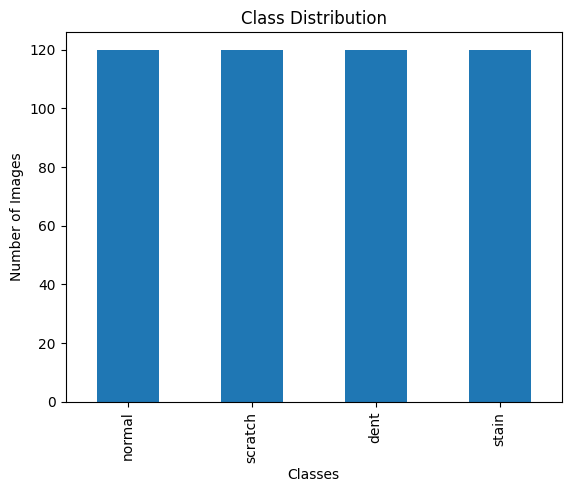

In [18]:
df['class'].value_counts().plot(kind='bar')

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

In [19]:
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array

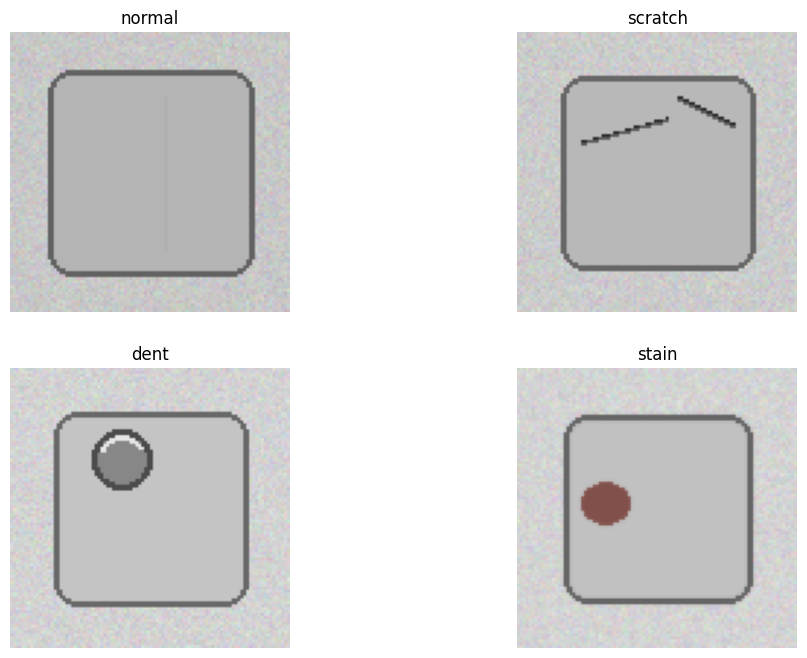

In [20]:
classes = df['class'].unique()

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    sample = df[df['class'] == cls].iloc[0]

    img_path = '/content/dataset/part_2_cnn_computer_vision/' + sample['filename']

    img = load_img(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.show()

In [22]:
sample_path = '/content/dataset/part_2_cnn_computer_vision/' + df['filename'][0]

sample_img = load_img(sample_path)

print("Image Size:", sample_img.size)

Image Size: (96, 96)


The dataset contains four image classes: dent, scratch, stain, and normal. Images are distributed across all categories. Sample images were visualized to understand the dataset structure and image dimensions.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [24]:
IMG_SIZE = 128

In [26]:
images = []

labels = []

In [28]:
for index, row in df.iterrows():

    path = '/content/dataset/part_2_cnn_computer_vision/' + row['filename']

    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))

    img = img_to_array(img)

    img = img / 255.0

    images.append(img)

    labels.append(row['class'])

In [29]:
X = np.array(images)

y = np.array(labels)

print(X.shape)

print(y.shape)

(480, 128, 128, 3)
(480,)


In [30]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_encoded = to_categorical(y_encoded)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

Image preprocessing was performed by resizing all images to 128×128 pixels and normalizing pixel values between 0 and 1. The dataset was divided into training and testing sets. Data augmentation techniques such as rotation, zooming, and horizontal flipping were applied to improve model generalization.

In [34]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [35]:
model = Sequential()

In [36]:
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [40]:
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

In [41]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [42]:
model.add(Flatten())

In [43]:
model.add(
    Dense(
        128,
        activation='relu'
    )
)

In [44]:
model.add(
    Dense(
        4,
        activation='softmax'
    )
)

In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 27, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441,412 (5.50 MB)

 Trainable params: 1,441,412 (5.50 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 886ms/step - accuracy: 0.2344 - loss: 1.4221 - val_accuracy: 0.2708 - val_loss: 1.3630
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 854ms/step - accuracy: 0.3802 - loss: 1.3214 - val_accuracy: 0.4896 - val_loss: 1.1588
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 701ms/step - accuracy: 0.5417 - loss: 1.0695 - val_accuracy: 0.7083 - val_loss: 0.8426
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 732ms/step - accuracy: 0.6406 - loss: 0.8557 - val_accuracy: 0.6667 - val_loss: 0.7755
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 768ms/step - accuracy: 0.7292 - loss: 0.6835 - val_accuracy: 0.8021 - val_loss: 0.5414
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 695ms/step - accuracy: 0.7995 - loss: 0.5469 - val_accuracy: 0.6250 - val_loss: 1.1765
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 637ms/step - accuracy: 0.8464 - loss: 0.4263 - val_accuracy: 0.6146 - val_loss: 1.0457
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 916ms/step - accuracy: 0.8724 - loss: 0.3332 - val_accurac

In [48]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

print("Test Loss:", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 0.8333 - loss: 0.3631
Test Accuracy: 0.8333333134651184
Test Loss: 0.36314037442207336


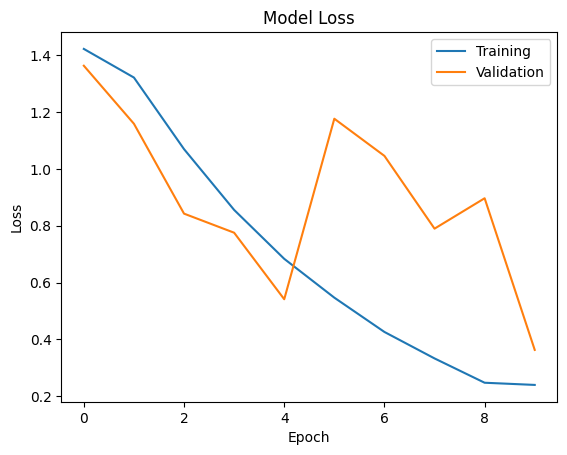

In [50]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step


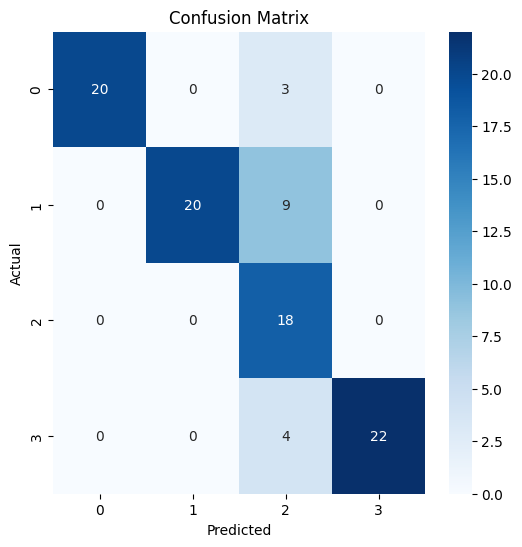

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


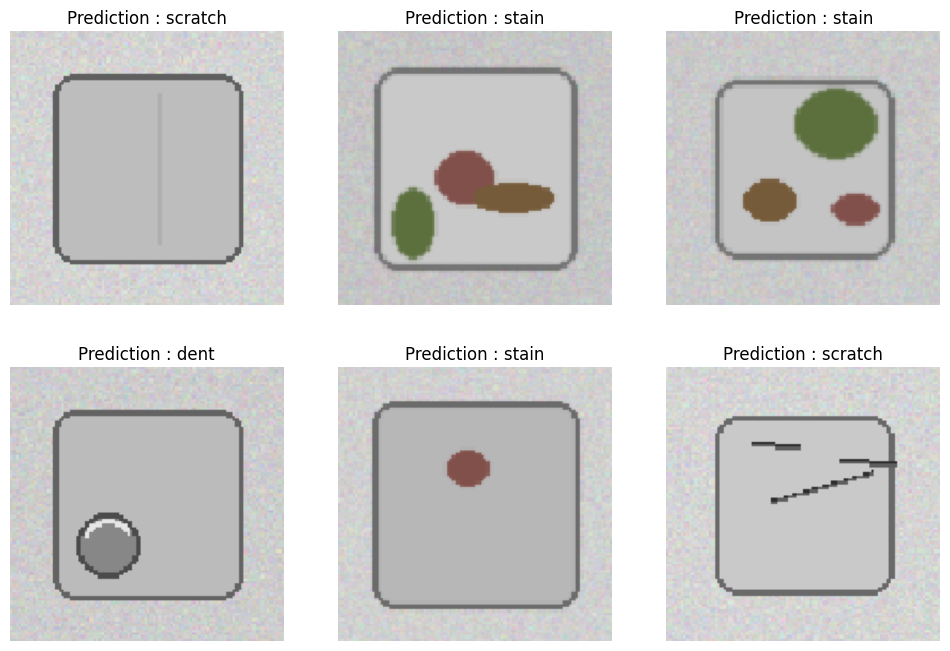

In [52]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    pred = np.argmax(
        model.predict(
            X_test[i].reshape(1,128,128,3)
        )
    )

    predicted_label = encoder.inverse_transform([pred])[0]

    plt.title("Prediction : " + predicted_label)

    plt.axis('off')

plt.show()

1. Convolution:
Convolution is a process where the CNN scans different parts of an image to identify patterns such as edges, textures, and shapes.

2. Pooling:
Pooling reduces image size while keeping important information. It helps reduce computation and improves efficiency.

3. ReLU:
ReLU is an activation function that helps the network learn complex patterns faster by removing negative values.

4. Why CNN is better:
CNNs are specifically designed for image data and automatically learn visual features, unlike regular neural networks.

This CNN-based defect detection system can be used in manufacturing industries for automatic quality inspection. The model can identify defects such as dents, scratches, and stains from product images, reducing manual inspection effort and improving production quality.